## Sportmonks Germany 201 — 04: Defensive compactness (proxies)

**Hypothesis (proxy):** a compact defensive block often correlates with **concentrated defensive actions** (tackles, interceptions, clearances, blocks) and **stable shape** (formation string consistency). This is **not** geometric compactness (no player x/y from Sportmonks alone).

Prerequisite: notebook 01 outputs.

In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

ROOT = Path.cwd()
if (ROOT / "sportmonks").is_dir():
    SPORTMONKS_DIR = ROOT / "sportmonks"
    sys.path.insert(0, str(SPORTMONKS_DIR))
else:
    SPORTMONKS_DIR = ROOT
    sys.path.insert(0, str(ROOT))

import sportmonks_germany_api as smg

In [2]:
load_dotenv(".env")

API_TOKEN = os.getenv("API_TOKEN")

In [3]:
GERMANY_TEAM_ID = int(
    json.loads((SPORTMONKS_DIR / "germany_201_meta.json").read_text(encoding="utf-8"))[
        "germany_team_id"
    ]
)
fixtures = pd.read_csv(SPORTMONKS_DIR / "fixtures_germany_201.csv", parse_dates=["starting_at"])

### Statistics + formations
Formation labels are provider-dependent; treat them as **ordinal descriptors**, not validated positional data.

In [4]:
MAX_FIXTURES = None
INCLUDE = "statistics.type;formations"


def pick(sd: dict, *keys: str) -> float:
    for k in keys:
        if k in sd and sd[k] == sd[k]:
            return float(sd[k])
    return float("nan")


def germany_formation_label(data: dict) -> str | None:
    fm = data.get("formations") or []
    if not fm:
        return None
    fdf = pd.json_normalize(fm)
    if "participant_id" not in fdf.columns:
        return None
    sub = fdf[fdf["participant_id"] == GERMANY_TEAM_ID]
    if sub.empty:
        return None
    for col in ("formation", "name", "formation_name"):
        if col in sub.columns:
            v = sub.iloc[0][col]
            if pd.notna(v):
                return str(v)
    return None


rows = []
ids = fixtures["id"].tolist()
if MAX_FIXTURES is not None:
    ids = ids[: int(MAX_FIXTURES)]

for fid in ids:
    data = smg.get_fixture(API_TOKEN, int(fid), INCLUDE)
    stats_df = smg.normalize_fixture_statistics(data)
    g = smg.stats_dict_for_team(stats_df, GERMANY_TEAM_ID)

    tackles = pick(g, "tackles", "TACKLES")
    interceptions = pick(g, "interceptions", "INTERCEPTIONS")
    clearances = pick(g, "clearances", "CLEARANCES")
    blocks = pick(
        g,
        "blocked-scoring-attempt",
        "blocked_scoring_attempt",
        "shots-blocked",
    )
    saves = pick(
        g,
        "saves",
        "goalkeeper-saves",
        "goalkeeper_saves",
        "SAVE_KEEPER",
    )
    fouls = pick(g, "fouls", "FOULS")

    defensive_sum = np.nansum([tackles, interceptions, clearances, blocks, saves])

    row_fix = fixtures.loc[fixtures["id"] == fid].iloc[0]
    rows.append(
        {
            "fixture_id": int(fid),
            "starting_at": row_fix["starting_at"],
            "league_id": int(row_fix["league_id"]),
            "ger_tackles": tackles,
            "ger_interceptions": interceptions,
            "ger_clearances": clearances,
            "ger_blocks": blocks,
            "ger_saves": saves,
            "ger_fouls": fouls,
            "defensive_compact_sum": defensive_sum,
            "formation_label": germany_formation_label(data),
        }
    )

def_df = pd.DataFrame(rows)
def_df.head()

,fixture_id,starting_at,league_id,ger_tackles,ger_interceptions,ger_clearances,ger_blocks,ger_saves,ger_fouls,defensive_compact_sum,formation_label
0,19032613,2024-06-14 19:00:00,1326,10.0,2.0,NaN,5.0,0.0,15.0,17.0,4-2-3-1
1,19032614,2024-06-19 16:00:00,1326,17.0,6.0,NaN,7.0,3.0,12.0,33.0,4-2-3-1
2,19032615,2024-06-23 19:00:00,1326,17.0,7.0,NaN,5.0,2.0,12.0,31.0,4-2-3-1
3,19032605,2024-06-29 19:00:00,1326,7.0,8.0,NaN,1.0,2.0,7.0,18.0,4-2-3-1
4,19032601,2024-07-05 16:00:00,1326,23.0,9.0,NaN,7.0,4.0,22.0,43.0,4-2-3-1


In [5]:
out = SPORTMONKS_DIR / "germany_defensive_features.csv"
def_df.to_csv(out, index=False)

In [6]:
league_labels = {1326: "Euro 2024", 1538: "Nations League 25", 720: "WCQ Europe"}
def_df["competition"] = def_df["league_id"].map(league_labels).fillna(
    def_df["league_id"].astype(str)
)

def_df.groupby("competition").agg(
    matches=("fixture_id", "count"),
    def_actions_median=("defensive_compact_sum", "median"),
    unique_formations=("formation_label", lambda s: s.dropna().nunique()),
)

,matches,def_actions_median,unique_formations
competition,,,
Euro 2024,5,31.0,1
Nations League 25,10,34.0,3
WCQ Europe,6,22.0,4


In [7]:
vc = def_df["formation_label"].value_counts(dropna=True).head(12)
vc

formation_label
4-2-3-1    16
3-4-2-1     2
4-1-3-2     1
4-4-1-1     1
4-3-3       1
Name: count, dtype: int64

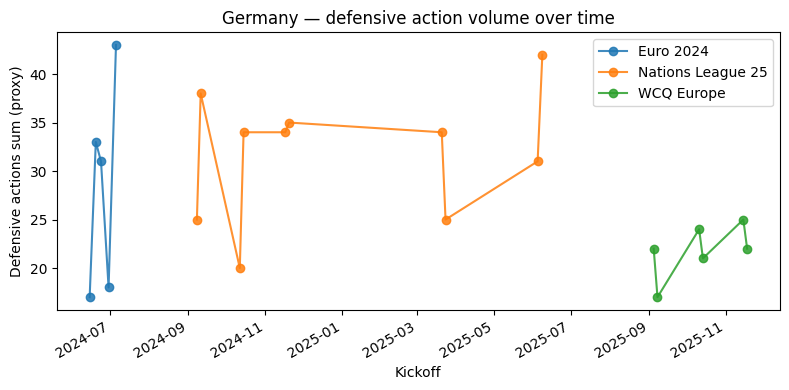

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
for comp, sub in def_df.groupby("competition"):
    sub = sub.sort_values("starting_at")
    ax.plot(
        sub["starting_at"],
        sub["defensive_compact_sum"],
        marker="o",
        linestyle="-",
        label=comp,
        alpha=0.85,
    )
ax.set_ylabel("Defensive actions sum (proxy)")
ax.set_xlabel("Kickoff")
ax.legend()
ax.set_title("Germany — defensive action volume over time")
fig.autofmt_xdate()
plt.tight_layout()